# Waymo Open Motion Dataset: Read and Inspect Locally

This notebook is adapted from the official Waymo motion tutorial and tailored to your local dataset path:

- Dataset root: `/mnt/disk/data/public/waymo`
- Goal: learn how to open TFRecord files, parse `Scenario` protos, and inspect tracks/map data

Reference tutorial: https://github.com/waymo-research/waymo-open-dataset/blob/master/tutorial/tutorial_motion.ipynb

## 1) Installation (run once per environment)

1. uv sync
2. change .env file to set `WAYMO_DATA_ROOT` to your dataset path (e.g. `/mnt/disk/data/public/waymo`)

## 2) Imports and global config

In [29]:
from pathlib import Path
from dotenv import load_dotenv
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from waymo_open_dataset.protos import scenario_pb2

load_dotenv()

DATASET_ROOT = Path(os.environ.get('WAYMO_DATA_ROOT'))
print('TensorFlow:', tf.__version__)
print('Dataset root exists:', DATASET_ROOT.exists())
print('Dataset root:', DATASET_ROOT)

TensorFlow: 2.12.0
Dataset root exists: True
Dataset root: /mnt/disk/data/public/waymo/motion_v_1_3_1/scenario


## 3) Discover motion TFRecord files

This searches recursively under `/mnt/disk/data/public/waymo` for `.tfrecord` files.

In [30]:
all_tfrecords = sorted(DATASET_ROOT.rglob('*.tfrecord*'))
print('Found', len(all_tfrecords), 'TFRecord-like files')
for p in all_tfrecords[:20]:
    print('-', p)
if len(all_tfrecords) > 20:
    print('... (showing first 20)')

Found 1300 TFRecord-like files
- /mnt/disk/data/public/waymo/motion_v_1_3_1/scenario/testing/testing.tfrecord-00000-of-00150
- /mnt/disk/data/public/waymo/motion_v_1_3_1/scenario/testing/testing.tfrecord-00001-of-00150
- /mnt/disk/data/public/waymo/motion_v_1_3_1/scenario/testing/testing.tfrecord-00002-of-00150
- /mnt/disk/data/public/waymo/motion_v_1_3_1/scenario/testing/testing.tfrecord-00003-of-00150
- /mnt/disk/data/public/waymo/motion_v_1_3_1/scenario/testing/testing.tfrecord-00004-of-00150
- /mnt/disk/data/public/waymo/motion_v_1_3_1/scenario/testing/testing.tfrecord-00005-of-00150
- /mnt/disk/data/public/waymo/motion_v_1_3_1/scenario/testing/testing.tfrecord-00006-of-00150
- /mnt/disk/data/public/waymo/motion_v_1_3_1/scenario/testing/testing.tfrecord-00007-of-00150
- /mnt/disk/data/public/waymo/motion_v_1_3_1/scenario/testing/testing.tfrecord-00008-of-00150
- /mnt/disk/data/public/waymo/motion_v_1_3_1/scenario/testing/testing.tfrecord-00009-of-00150
- /mnt/disk/data/public/waymo

## 4) Pick one file and parse a scenario

Each record in a motion TFRecord is serialized as `waymo_open_dataset.protos.Scenario`.

In [31]:
if not all_tfrecords:
    raise FileNotFoundError(f'No TFRecord files found under {DATASET_ROOT}')

TFRECORD_PATH = all_tfrecords[0]  # change to any file you want
print('Using TFRecord:', TFRECORD_PATH)

def parse_scenario(serialized_bytes):
    scenario = scenario_pb2.Scenario()
    scenario.ParseFromString(serialized_bytes)
    return scenario

dataset = tf.data.TFRecordDataset([str(TFRECORD_PATH)], compression_type='')
first_record = next(iter(dataset.as_numpy_iterator()))
scenario = parse_scenario(first_record)
print('Parsed scenario_id:', scenario.scenario_id)

Using TFRecord: /mnt/disk/data/public/waymo/motion_v_1_3_1/scenario/testing/testing.tfrecord-00000-of-00150
Parsed scenario_id: 53efd22f9e0bd276


2026-04-10 09:59:47.517879: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [1]
	 [[{{node Placeholder/_0}}]]


In [32]:
print('num_timestamps:', scenario.timestamps_seconds.__len__())
print('num_tracks:', len(scenario.tracks))
print('num_map_features:', len(scenario.map_features))
print('num_dynamic_map_states:', len(scenario.dynamic_map_states))
print('sdc_track_index:', scenario.sdc_track_index)

num_timestamps: 11
num_tracks: 49
num_map_features: 175
num_dynamic_map_states: 11
sdc_track_index: 48


## 5) Convert track states to a table

This flattens every `(track, timestep)` into one row for quick inspection in pandas.

In [33]:
def tracks_to_dataframe(scenario_msg):
    rows = []
    for t_idx, trk in enumerate(scenario_msg.tracks):
        for s_idx, st in enumerate(trk.states):
            rows.append({
                'track_array_index': t_idx,
                'track_id': trk.id,
                'object_type': trk.object_type,
                'step': s_idx,
                'valid': bool(st.valid),
                'x': st.center_x,
                'y': st.center_y,
                'z': st.center_z,
                'length': st.length,
                'width': st.width,
                'height': st.height,
                'heading': st.heading,
                'velocity_x': st.velocity_x,
                'velocity_y': st.velocity_y,
            })
    return pd.DataFrame(rows)

tracks_df = tracks_to_dataframe(scenario)
print('rows:', len(tracks_df))
tracks_df.head(10)

rows: 539


,track_array_index,track_id,object_type,step,valid,x,y,z,length,width,height,heading,velocity_x,velocity_y
0,0,259,1,0,True,316.864594,7953.306152,121.391997,12.407690,3.026143,3.366674,1.554057,-0.043945,-0.722656
1,0,259,1,1,True,316.862671,7952.961426,121.432368,11.541391,3.012834,3.357359,1.560126,-0.019226,-3.447266
2,0,259,1,2,True,316.878387,7952.571777,121.448081,10.418606,2.932749,3.396519,1.564758,0.157166,-3.896484
3,0,259,1,3,True,316.874542,7952.536133,121.449672,10.214058,2.913740,3.392214,1.566990,-0.038452,-0.356445
4,0,259,1,4,True,316.867035,7952.495117,121.461774,10.007646,2.895425,3.330856,1.569770,-0.075073,-0.410156
5,0,259,1,5,True,316.866455,7952.495605,121.472635,9.771669,2.895436,3.348182,1.571717,-0.005798,0.004883
6,0,259,1,6,True,316.869751,7952.539551,121.475328,9.574150,2.902854,3.349398,1.573136,0.032959,0.439453
7,0,259,1,7,True,316.865845,7952.576660,121.458748,9.432716,2.916066,3.299553,1.579485,-0.039062,0.371094
8,0,259,1,8,True,316.865601,7952.528809,121.464560,9.346997,2.925177,3.311004,1.587031,-0.002441,-0.478516
9,0,259,1,9,True,316.871246,7952.499023,121.471090,9.149102,2.953568,3.295463,1.593139,0.056458,-0.297852


In [34]:
valid_df = tracks_df[tracks_df['valid']]
print('Unique tracks with at least one valid state:', valid_df['track_id'].nunique())
print('Counts by object_type:')
print(valid_df.groupby('object_type')['track_id'].nunique().sort_values(ascending=False))

Unique tracks with at least one valid state: 31
Counts by object_type:
object_type
1    24
2     7
Name: track_id, dtype: int64


## 6) Inspect map feature types

In [35]:
def map_feature_kind(feature):
    # Returns which oneof field is set for this map feature.
    return feature.WhichOneof('feature_data')

map_kinds = pd.Series([map_feature_kind(f) for f in scenario.map_features])
map_kinds.value_counts(dropna=False)

lane         103
driveway      28
road_line     23
road_edge     15
crosswalk      4
stop_sign      2
dtype: int64

## 7) Quick 2D trajectory plot

This plots valid XY history for a random subset of tracks in one scenario.

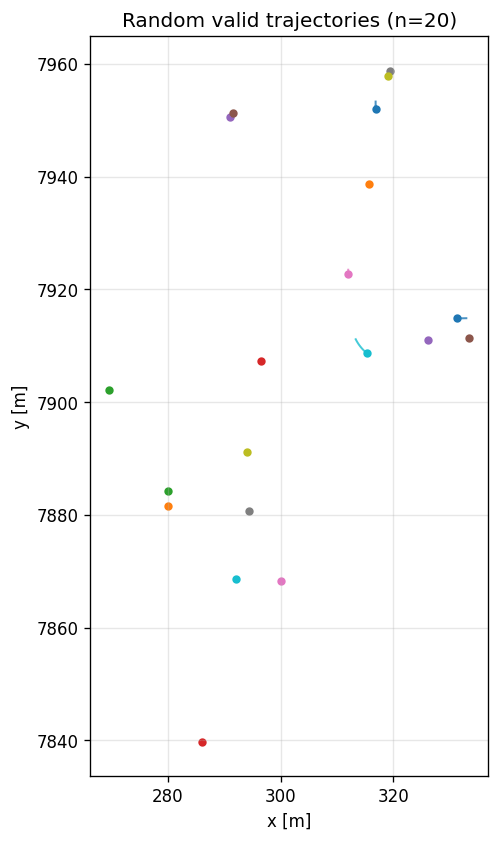

In [36]:
def plot_random_tracks(df, num_tracks=20, seed=0):
    from io import BytesIO
    from matplotlib.figure import Figure
    from IPython.display import Image, display

    rng = random.Random(seed)
    valid = df[df['valid']].copy()
    track_ids = valid['track_id'].drop_duplicates().tolist()
    if not track_ids:
        raise ValueError('No valid tracks to plot.')

    chosen = set(rng.sample(track_ids, k=min(num_tracks, len(track_ids))))
    subset = valid[valid['track_id'].isin(chosen)].sort_values(['track_id', 'step'])

    # Avoid pyplot backend issues by using Matplotlib's OO Figure API directly.
    fig = Figure(figsize=(8, 8))
    ax = fig.subplots()

    for tid, g in subset.groupby('track_id'):
        ax.plot(g['x'], g['y'], linewidth=1.2, alpha=0.8)
        ax.scatter(g['x'].iloc[-1], g['y'].iloc[-1], s=16)

    ax.set_title(f'Random valid trajectories (n={len(chosen)})')
    ax.set_xlabel('x [m]')
    ax.set_ylabel('y [m]')
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, alpha=0.3)

    # Force image rendering in notebook output even when Figure mime rendering is unavailable.
    buffer = BytesIO()
    fig.savefig(buffer, format='png', dpi=120, bbox_inches='tight')
    buffer.seek(0)
    display(Image(data=buffer.getvalue()))
    buffer.close()

plot_random_tracks(tracks_df, num_tracks=20, seed=42)

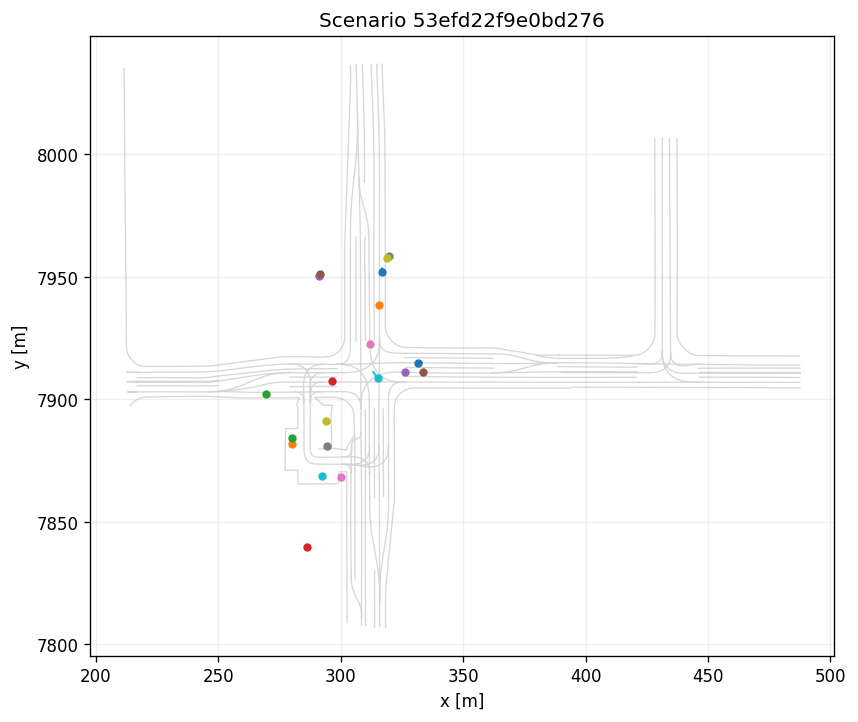

In [38]:
def plot_map_and_tracks(scenario_msg, df, num_tracks=20, seed=0):
    from io import BytesIO
    from matplotlib.figure import Figure
    from IPython.display import Image, display
    import random

    fig = Figure(figsize=(8, 8))
    ax = fig.subplots()

    # plot map
    for feat in scenario_msg.map_features:
        kind = feat.WhichOneof("feature_data")

        if kind == "lane":
            pts = feat.lane.polyline
        elif kind == "road_line":
            pts = feat.road_line.polyline
        elif kind == "road_edge":
            pts = feat.road_edge.polyline
        else:
            continue

        if len(pts) >= 2:
            xs = [p.x for p in pts]
            ys = [p.y for p in pts]
            ax.plot(xs, ys, color="lightgray", linewidth=0.8, alpha=0.9, zorder=1)

    # plot random valid tracks
    rng = random.Random(seed)
    valid = df[df["valid"]].copy()
    track_ids = valid["track_id"].drop_duplicates().tolist()
    chosen = set(rng.sample(track_ids, k=min(num_tracks, len(track_ids))))
    subset = valid[valid["track_id"].isin(chosen)].sort_values(["track_id", "step"])

    for tid, g in subset.groupby("track_id"):
        ax.plot(g["x"], g["y"], linewidth=1.4, alpha=0.9, zorder=2)
        ax.scatter(g["x"].iloc[-1], g["y"].iloc[-1], s=16, zorder=3)

    ax.set_title(f"Scenario {scenario_msg.scenario_id}")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.2)

    buffer = BytesIO()
    fig.savefig(buffer, format="png", dpi=120, bbox_inches="tight")
    buffer.seek(0)
    display(Image(data=buffer.getvalue()))
    buffer.close()

plot_map_and_tracks(scenario, tracks_df, num_tracks=20, seed=42)


## 8) Iterate over multiple scenarios

Use this pattern when building training/evaluation pipelines.

In [37]:
def iter_scenarios(tfrecord_path, max_scenarios=None):
    ds = tf.data.TFRecordDataset([str(tfrecord_path)], compression_type='')
    for i, raw in enumerate(ds):
        if max_scenarios is not None and i >= max_scenarios:
            break
        s = scenario_pb2.Scenario()
        s.ParseFromString(raw.numpy())
        yield s

for i, s in enumerate(iter_scenarios(TFRECORD_PATH, max_scenarios=3), start=1):
    print(f'{i}. scenario_id={s.scenario_id}, tracks={len(s.tracks)}, map_features={len(s.map_features)}')

1. scenario_id=53efd22f9e0bd276, tracks=49, map_features=175
2. scenario_id=4b1f67e58e15e78c, tracks=21, map_features=212
3. scenario_id=81cb7891dfe69679, tracks=45, map_features=337


2026-04-10 09:59:47.837824: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [1]
	 [[{{node Placeholder/_0}}]]


## 9) Next steps

- Change `TFRECORD_PATH` to target specific train/val/test shards.
- Extend extraction with lane centerlines / traffic lights for model features.
- Wrap `iter_scenarios` into a PyTorch or TensorFlow dataloader pipeline.